# Linear vs Non-Linear Regression Demonstration Using Advertising Data

In [1]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# Step 2: Load the Dataset

data = pd.read_csv('advertising_nonlinear.csv')

In [3]:
data.head()

,TV,Radio,Newspaper,Sales,Sales_Nonlinear
0,230.1,37.8,69.2,22.1,5.35
1,44.5,39.3,45.1,10.4,7.20
2,17.2,45.9,69.3,12.0,7.77
3,151.5,41.3,58.5,16.5,9.82
4,180.8,10.8,58.4,17.9,5.66


In [6]:
# Step 3: Select Features and Target

x = data[['TV', 'Radio']]
y_linear = data['Sales_Nonlinear']

In [7]:
x.head()

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8


In [8]:
y_linear.head()

0    5.35
1    7.20
2    7.77
3    9.82
4    5.66
Name: Sales_Nonlinear, dtype: float64

In [9]:
# Step 4: Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y_linear, test_size=0.2, random_state=42)

In [10]:
# Step 5: Apply Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict
y_pred_linear = lin_reg.predict(X_test)

In [12]:
# Evaluate Linear Model
r2_lin = r2_score(y_test, y_pred_linear)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_linear))


print("Linear Regression R²:", round(r2_lin, 3))
print("Linear Regression RMSE:", round(rmse_lin, 3))

Linear Regression R²: 0.269
Linear Regression RMSE: 2.144


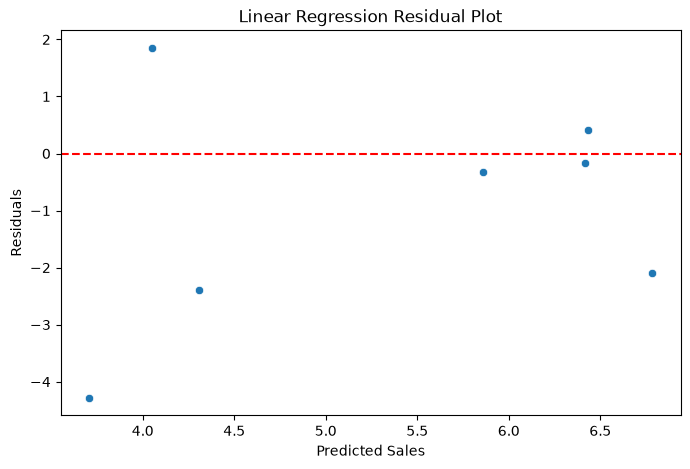

In [13]:
# Plot Residuals for Linear Regression
residuals_lin = y_test - y_pred_linear
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_linear, y=residuals_lin)
plt.axhline(0, color='red', linestyle='--')
plt.title('Linear Regression Residual Plot')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.show()

In [14]:
# Step 6: Apply Polynomial Regression (Degree 2)

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

# Create polynomial features (degree=2) to capture non-linear relationships

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [15]:
poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# Predict
y_pred_poly = poly_reg.predict(X_poly_test)